In [2]:
import datetime as dt

import polars as pl
import sf_quant.data as sfd
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
start = dt.date(2000, 1, 1)
end = dt.date(2024, 12, 31)
signal_name = "satv_z"
gamma = 50
price_filter = 5
backtest_start = dt.date(2011, 1, 1)

/home/msch2022/SATV/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-08 09:12:38,587	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
# Load MVO weights
weights = pl.read_parquet(f"weights/{signal_name}/{gamma}/*.parquet")

# Load returns + spread + price
returns = (
    sfd.load_assets(
        start=start,
        end=end,
        columns=["date", "barrid", "return", "bid_ask_spread", "price"],
        in_universe=True
    )
    .sort("date", "barrid")
    .select(
        "date",
        "barrid",

        # forward return (convert % -> decimal)
        pl.col("return")
        .truediv(100)
        .shift(-1)
        .over("barrid")
        .alias("forward_return"),

        # spread as % of price (decimal)
        (-pl.col("bid_ask_spread") / pl.col("price")).alias("spread_pct"),
    )
)


In [4]:
# Rebuild SATV signal exactly from the alpha job logic
signal_data = sfd.load_assets(
    start=start,
    end=end,
    columns=[
        "date",
        "barrid",
        "price",
        "return",
        "specific_risk",
        "predicted_beta",
        "market_cap",
        "daily_volume",
        "bid_ask_spread",
    ],
    in_universe=True,
).with_columns(
    pl.col("return", "specific_risk").truediv(100)
)

satv_z = (
    signal_data
    .sort("date", "barrid")
    .with_columns(
        (pl.col("market_cap") / pl.col("price")).alias("shrout"),
        (pl.col("daily_volume") / (pl.col("market_cap") / pl.col("price"))).alias("turnover"),
    )
    .with_columns(
        pl.col("turnover")
        .rolling_mean(230)
        .shift(21)
        .over("barrid")
        .alias("turnover_mean"),

        pl.col("turnover")
        .rolling_std(230)
        .shift(21)
        .over("barrid")
        .alias("turnover_std"),
    )
    .with_columns(
        ((pl.col("turnover") - pl.col("turnover_mean")) / pl.col("turnover_std")).alias("satv_z")
    )
)

filtered_signal = satv_z.filter(
    pl.col("price").shift(1).over("barrid").gt(price_filter),
    pl.col(signal_name).is_not_null(),
    pl.col("predicted_beta").is_not_null(),
    pl.col("specific_risk").is_not_null(),
).select("date", "barrid", signal_name)

In [7]:
# ============================================================
# Daily diagnostics: IC, turnover, breadth
# Breadth here = effective number of names = 1 / sum(w^2)
# This is the cleanest daily-rebalanced breadth measure for MVO weights.
# ============================================================

# Daily IC
ic_by_date = (
    filtered_signal
    .join(
        returns.select("date", "barrid", "forward_return"),
        on=["date", "barrid"],
        how="inner",
    )
    .drop_nulls([signal_name, "forward_return"])
    .group_by("date")
    .agg(
        pl.corr(signal_name, "forward_return").alias("ic"),
        pl.len().alias("n_names_ic"),
    )
    .sort("date")
    .filter(pl.col("date") >= backtest_start)
)

ic_summary = ic_by_date.select(
    pl.col("ic").mean().alias("ic")
)

# Daily turnover from weights
# For a daily rebalanced portfolio, this is the one-way daily turnover:
# 0.5 * sum_i |w_t - w_{t-1}|
turnover_by_date = (
    weights
    .sort("barrid", "date")
    .with_columns(
        pl.col("weight").shift(1).over("barrid").fill_null(0.0).alias("prev_weight")
    )
    .group_by("date")
    .agg(
        (pl.col("weight") - pl.col("prev_weight")).abs().sum().mul(0.5).alias("turnover"),
        pl.col("weight").abs().sum().alias("gross_exposure"),
        pl.len().alias("n_rows"),
    )
    .sort("date")
    .filter(pl.col("date") >= backtest_start)
)

turnover_summary = turnover_by_date.select(
    pl.col("turnover").mean().alias("turnover")
)

# Daily breadth
# Effective breadth / effective number of names:
# breadth_t = 1 / sum_i w_{i,t}^2
# This is usually what you want for a daily-rebalanced active book.
breadth_by_date = (
    weights
    .group_by("date")
    .agg(
        pl.col("weight").pow(2).sum().alias("sum_w2"),
        pl.col("weight").abs().sum().alias("gross_exposure"),
        pl.len().alias("n_names"),
    )
    .with_columns(
        pl.when(pl.col("sum_w2") > 0)
        .then(1.0 / pl.col("sum_w2"))
        .otherwise(None)
        .alias("breadth")
    )
    .sort("date")
    .filter(pl.col("date") >= backtest_start)
)

breadth_summary = breadth_by_date.select(
    pl.col("breadth").mean().alias("breadth")
)

# Optional smoothing for cleaner charts
ic_plot = (
    ic_by_date
    .with_columns(
        pl.col("ic").rolling_mean(63).alias("ic_63d_mean")
    )
)

turnover_plot = (
    turnover_by_date
    .with_columns(
        pl.col("turnover").rolling_mean(21).alias("turnover_21d_mean")
    )
)

breadth_plot = (
    breadth_by_date
    .with_columns(
        pl.col("breadth").rolling_mean(21).alias("breadth_21d_mean")
    )
)

# Helper: call this AFTER your two cumulative-return charts
def plot_diagnostics():
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    # Turnover
    axes[0].plot(
        turnover_plot["date"].to_list(),
        turnover_plot["turnover"].to_list(),
        alpha=0.35,
        label="Daily turnover",
    )
    axes[0].plot(
        turnover_plot["date"].to_list(),
        turnover_plot["turnover_21d_mean"].to_list(),
        linewidth=2,
        label="21D mean",
    )
    axes[0].set_title("Daily Turnover")
    axes[0].set_ylabel("Turnover")
    axes[0].legend()

    # IC
    axes[1].plot(
        ic_plot["date"].to_list(),
        ic_plot["ic"].to_list(),
        alpha=0.25,
        label="Daily IC",
    )
    axes[1].plot(
        ic_plot["date"].to_list(),
        ic_plot["ic_63d_mean"].to_list(),
        linewidth=2,
        label="63D mean",
    )
    axes[1].axhline(0.0, linestyle="--", linewidth=1)
    axes[1].set_title(f"Daily IC: {signal_name} vs next-day return")
    axes[1].set_ylabel("IC")
    axes[1].legend()

    # Breadth
    axes[2].plot(
        breadth_plot["date"].to_list(),
        breadth_plot["breadth"].to_list(),
        alpha=0.35,
        label="Daily breadth",
    )
    axes[2].plot(
        breadth_plot["date"].to_list(),
        breadth_plot["breadth_21d_mean"].to_list(),
        linewidth=2,
        label="21D mean",
    )
    axes[2].set_title("Daily Breadth (Effective Number of Names)")
    axes[2].set_ylabel("Breadth")
    axes[2].set_xlabel("")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

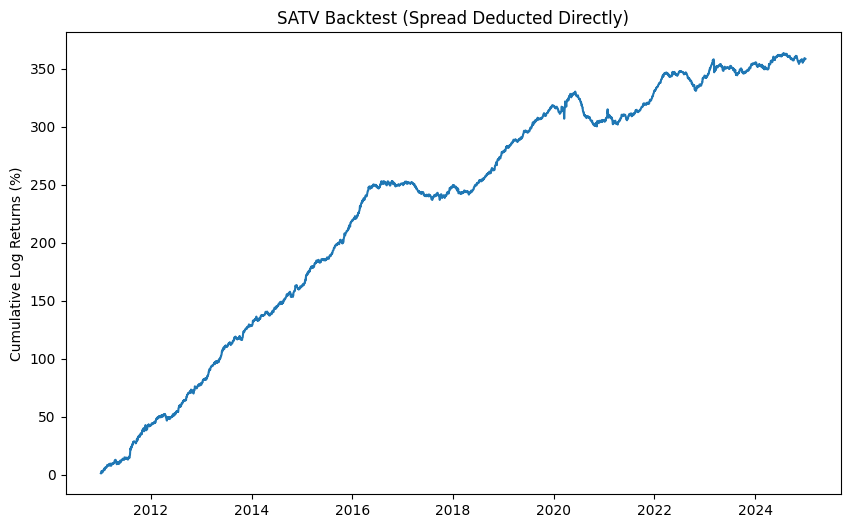

shape: (1, 5)
┌─────────────┬────────────┬──────────┬──────────┬──────────┐
│ mean_return ┆ volatility ┆ sharpe   ┆ ic       ┆ turnover │
│ ---         ┆ ---        ┆ ---      ┆ ---      ┆ ---      │
│ f64         ┆ f64        ┆ f64      ┆ f64      ┆ f64      │
╞═════════════╪════════════╪══════════╪══════════╪══════════╡
│ 26.266171   ┆ 10.958295  ┆ 2.396921 ┆ 0.006767 ┆ 3.152314 │
└─────────────┴────────────┴──────────┴──────────┴──────────┘


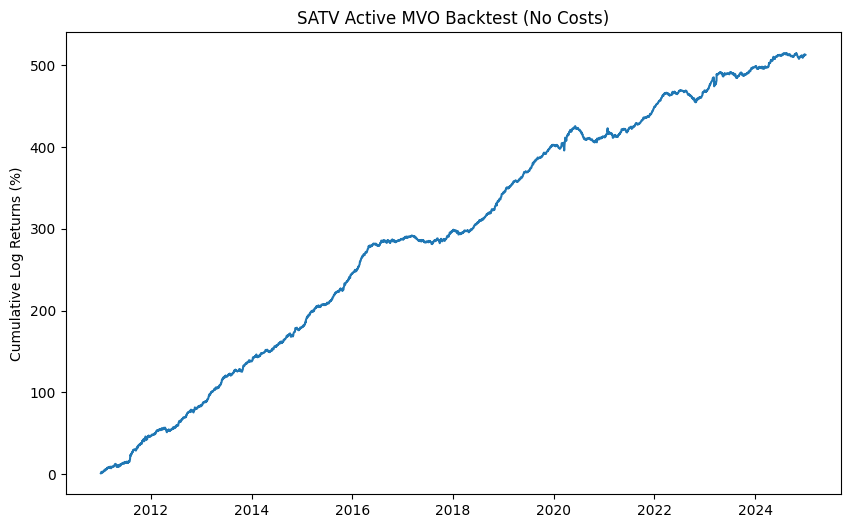

shape: (1, 5)
┌─────────────┬────────────┬──────────┬──────────┬──────────┐
│ mean_return ┆ volatility ┆ sharpe   ┆ ic       ┆ turnover │
│ ---         ┆ ---        ┆ ---      ┆ ---      ┆ ---      │
│ f64         ┆ f64        ┆ f64      ┆ f64      ┆ f64      │
╞═════════════╪════════════╪══════════╪══════════╪══════════╡
│ 37.336372   ┆ 11.16024   ┆ 3.345481 ┆ 0.006767 ┆ 3.152314 │
└─────────────┴────────────┴──────────┴──────────┴──────────┘


In [8]:
# Compute portfolio returns (spread deducted directly)
portfolio_returns = (
    weights.join(other=returns, on=["date", "barrid"], how="left")
    .with_columns(
        (
            pl.col("forward_return") - pl.col("spread_pct") / 2
        ).mul(pl.col("weight")).alias("net_contribution")
    )
    .group_by("date")
    .agg(pl.col("net_contribution").sum().alias("return"))
    .sort("date")
)

portfolio_returns = portfolio_returns.filter(pl.col("date") >= backtest_start)

# Compute cumulative log returns
cumulative_returns = portfolio_returns.select(
    "date",
    pl.col("return").log1p().cum_sum().mul(100).alias("cumulative_return")
)

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(cumulative_returns, x="date", y="cumulative_return")
plt.title("SATV Backtest (Spread Deducted Directly)")
plt.xlabel("")
plt.ylabel("Cumulative Log Returns (%)")
plt.show()

# Summary stats
summary = (
    portfolio_returns.select(
        pl.col("return").mean().mul(252 * 100).alias("mean_return"),
        pl.col("return").std().mul(pl.lit(252).sqrt() * 100).alias("volatility"),
    )
    .with_columns(
        pl.col("mean_return").truediv(pl.col("volatility")).alias("sharpe")
    )
    .hstack(ic_summary)
    .hstack(turnover_summary)
)

print(summary)

# Compute portfolio returns (NO spread cost)
portfolio_returns = (
    weights.join(other=returns, on=["date", "barrid"], how="left")
    .group_by("date")
    .agg(pl.col("forward_return").mul(pl.col("weight")).sum().alias("return"))
    .sort("date")
)

portfolio_returns = portfolio_returns.filter(pl.col("date") >= backtest_start)

# Compute cumulative log returns
cumulative_returns = portfolio_returns.select(
    "date",
    pl.col("return").log1p().cum_sum().mul(100).alias("cumulative_return")
)

# Plot cumulative log returns
plt.figure(figsize=(10, 6))
sns.lineplot(cumulative_returns, x="date", y="cumulative_return")
plt.title("SATV Active MVO Backtest (No Costs)")
plt.xlabel("")
plt.ylabel("Cumulative Log Returns (%)")
plt.savefig("backtest_chart.png")
plt.show()

# Create summary table
summary = (
    portfolio_returns.select(
        pl.col("return").mean().mul(252 * 100).alias("mean_return"),
        pl.col("return").std().mul(pl.lit(252).sqrt() * 100).alias("volatility"),
    )
    .with_columns(
        pl.col("mean_return").truediv(pl.col("volatility")).alias("sharpe")
    )
    .hstack(ic_summary)
    .hstack(turnover_summary)
)

print(summary)

In [9]:
summary = (
    portfolio_returns.select(
        pl.col("return").mean().mul(252 * 100).alias("mean_return"),
        pl.col("return").std().mul(pl.lit(252).sqrt() * 100).alias("volatility"),
    )
    .with_columns(
        pl.col("mean_return").truediv(pl.col("volatility")).alias("sharpe")
    )
)

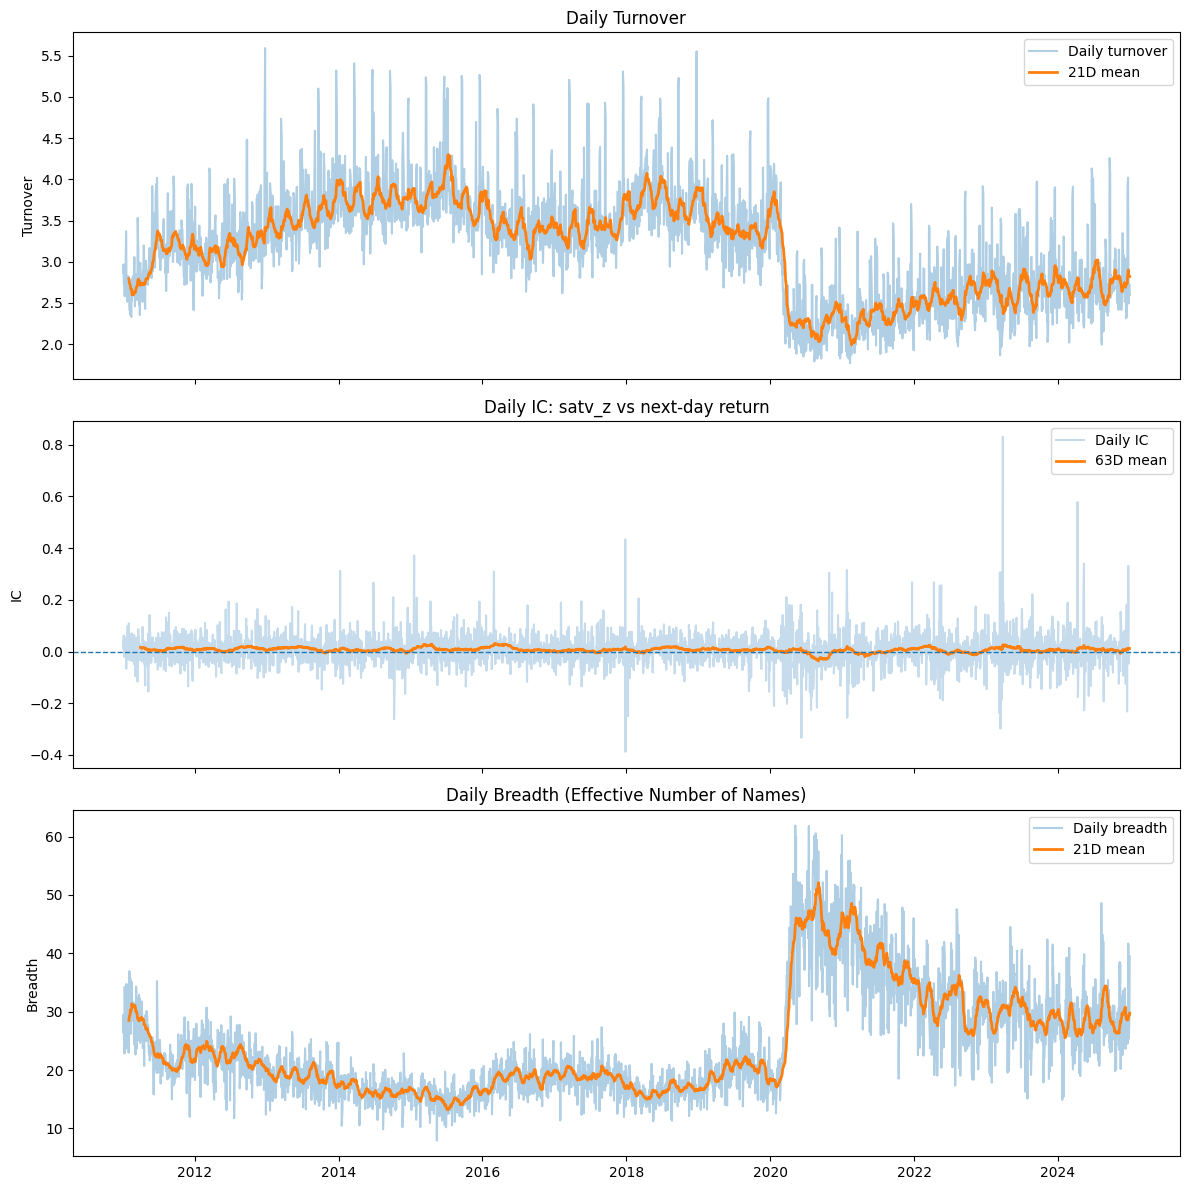

shape: (1, 3)
┌──────────────┬──────────┬─────────────┐
│ avg_turnover ┆ avg_ic   ┆ avg_breadth │
│ ---          ┆ ---      ┆ ---         │
│ f64          ┆ f64      ┆ f64         │
╞══════════════╪══════════╪═════════════╡
│ 3.152314     ┆ 0.006767 ┆ 24.258853   │
└──────────────┴──────────┴─────────────┘


In [10]:
plot_diagnostics()

print(
    pl.DataFrame({
        "avg_turnover": turnover_summary["turnover"],
        "avg_ic": ic_summary["ic"],
        "avg_breadth": breadth_summary["breadth"],
    })
)